#<font color = 'teal'>Netflix Data Visualization</font>

In [ ]:
# importing required Library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re

In [ ]:
# read the netflix data

netflix_df = pd.read_csv('netflix_titles.csv')

In [ ]:
# first 5 rows

netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# last 5 rows

netflix_df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [ ]:
# check no. of rows and columns

netflix_df.shape

(8807, 12)

In [ ]:
# check column names

netflix_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
# column types

netflix_df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
# Check missing value

netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
# handling missing value in column director

netflix_df['director'] = netflix_df['director'].fillna('Not Specified')

In [ ]:
# handling missing value in column cast

netflix_df['cast'] = netflix_df['cast'].fillna('No Cast Information')

In [ ]:
# handling missing value in column country

netflix_df['country'] = netflix_df['country'].fillna('Not Specified')


In [ ]:
# handling missing value in column rating

netflix_df['rating'] = netflix_df['rating'].fillna('Not Rated')

In [ ]:
# Before handling missing value creating new column by extracting duration and its type

netflix_df["duration_value"] = netflix_df["duration"].str.extract(r'(\d+)').astype(float)


In [ ]:
# check the added column

netflix_df['duration_value']

,duration_value
0,90.0
1,2.0
2,1.0
3,1.0
4,2.0
...,...
8802,158.0
8803,2.0
8804,88.0
8805,88.0


In [ ]:
# convert duration type to string
netflix_df["duration"] = netflix_df["duration"].astype(str)


In [ ]:
# create new column as duration type

netflix_df["duration_type"] = (
    netflix_df["duration"]
    .str.extract(r'\b(min|season)s?\b', flags=re.IGNORECASE)[0]
    .str.lower()
)


In [ ]:
# check duration type column

netflix_df['duration_type']

,duration_type
0,min
1,season
2,season
3,season
4,season
...,...
8802,min
8803,season
8804,min
8805,min


In [ ]:
# handling missing value in columnn duration value

netflix_df['duration_value'] = netflix_df['duration_value'].fillna('Nan')

In [ ]:
# handling missing value in column duration type

netflix_df['duration_type'] = netflix_df['duration_type'].fillna('Nan')

In [ ]:
# handling missing value in column date added

netflix_df['date_added'] = netflix_df['date_added'].fillna('Nan')

In [ ]:
# create new dataframe with updation

updated_netflix_df = netflix_df.drop(['duration'], axis=1)

In [ ]:
# 1st 5rows of updated df

updated_netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Cast Information,United States,"September 25, 2021",2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90.0,min
1,s2,TV Show,Blood & Water,Not Specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Specified,"September 24, 2021",2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,season
3,s4,TV Show,Jailbirds New Orleans,Not Specified,No Cast Information,Not Specified,"September 24, 2021",2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,season
4,s5,TV Show,Kota Factory,Not Specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,season


In [ ]:
# last 5 rows

updated_netflix_df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_value,duration_type
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158.0,min
8803,s8804,TV Show,Zombie Dumb,Not Specified,No Cast Information,Not Specified,"July 1, 2019",2018,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2.0,season
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88.0,min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88.0,min
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,111.0,min


In [ ]:
# check update df shape

updated_netflix_df.shape # here column 13 bcz, we add 2 new column and drop 1 existing column

(8807, 13)

In [ ]:
# Check missing value for rupdate df

updated_netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
listed_in,0


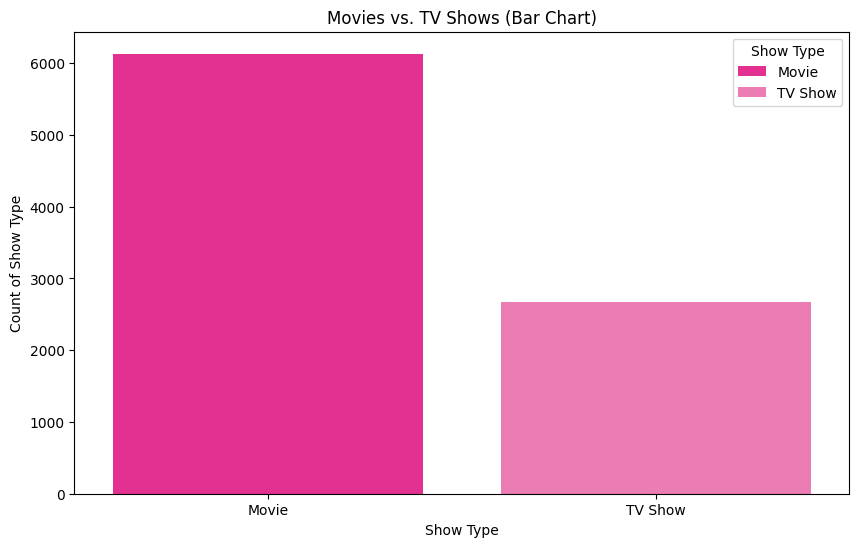

In [ ]:
# Movies v/s TV shows (Bar chart)

plt.figure(figsize=(10, 6))

color_palette = ['deeppink','hotpink']

sns.countplot(x='type',
              data=updated_netflix_df,
              palette=color_palette,
              hue='type',
              legend=True,
              )

plt.title('Movies vs. TV Shows (Bar Chart)')
plt.xlabel('Show Type')
plt.ylabel('Count of Show Type')
plt.legend(title='Show Type')

plt.show()

##<font color='dimgrey'>**Movies v/s TV shows (Bar chart)** </font>

<font color = 'slategrey'>
We conclude from the visual </font>


<font color = 'slategrey'>

*  Movies are higher than TV shows
*   Netflix contains more movies than TV shows

</font>

<function matplotlib.pyplot.show(close=None, block=None)>

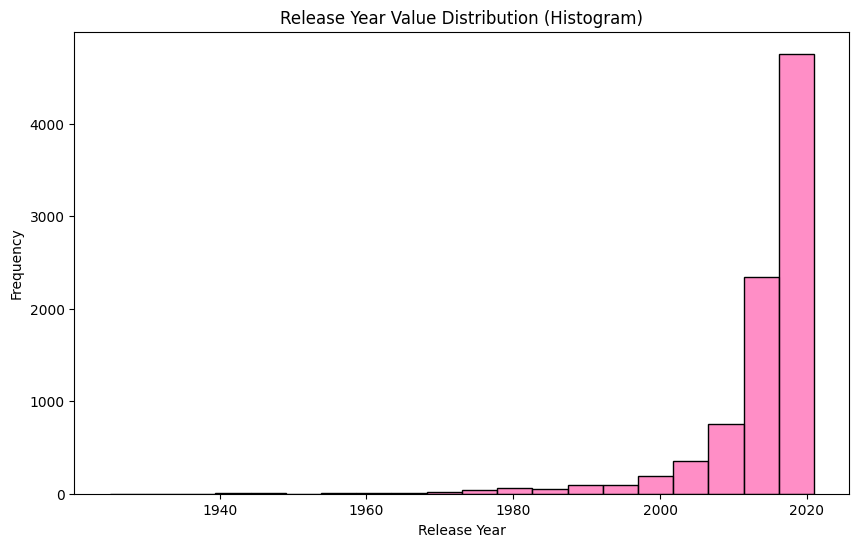

In [ ]:
# Release year value distribution (Histogram)

plt.figure(figsize=(10, 6))

sns.histplot(data=updated_netflix_df,
             x='release_year',
             bins=20,
             color='hotpink')

plt.title('Release Year Value Distribution (Histogram)')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show

##<font color='dimgrey'>**Release year value distribution (Histogram)** </font>

<font color = 'slategrey'>
We conclude from the visual </font>


<font color = 'slategrey'>

*  This is the left skewed(Negatively) distribution
*  From 2000 onwards there is a noticeable increase in platform activity

</font>

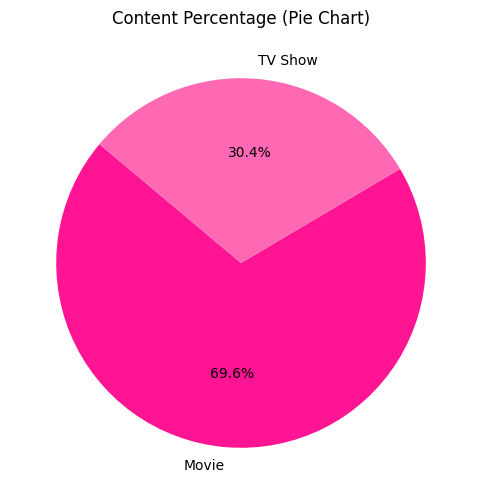

In [ ]:
# Content percentage (Pie chart)

plt.figure(figsize=(10, 6))

color_palette = ['deeppink','hotpink']

plt.pie(updated_netflix_df['type'].value_counts(),
        labels=updated_netflix_df['type'].unique(),
        colors=color_palette,
        autopct='%1.1f%%',
        startangle=140)

plt.title('Content Percentage (Pie Chart)')

plt.show()

##<font color='dimgrey'>**Content percentage (Pie chart)** </font>

<font color = 'slategrey'>
We conclude from the visual </font>


<font color = 'slategrey'>

*  Movies are highest content in the netflix platform

</font>

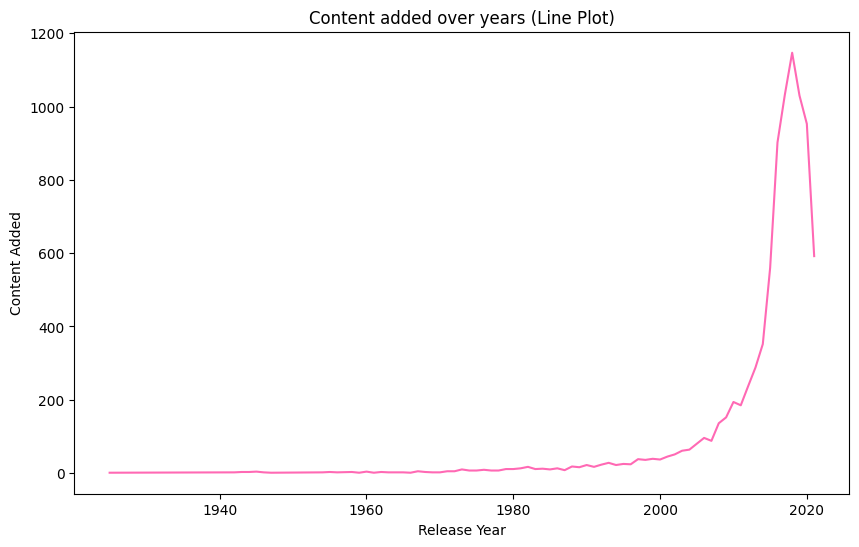

In [ ]:
# Netflix content added over years (Line plot)

plt.figure(figsize=(10, 6))

estimator_value = updated_netflix_df.groupby('release_year')['show_id'].count().reset_index(name='content_count')

sns.lineplot(
    data=estimator_value,
    x='release_year',
    y='content_count',
    color='hotpink'
)

plt.title('Content added over years (Line Plot)')
plt.xlabel('Release Year')
plt.ylabel('Content Added')

plt.show()

##<font color='dimgrey'>**Netflix content added over years (Line plot)** </font>

<font color = 'slategrey'>
We conclude from the visual </font>


<font color = 'slategrey'>

*  Content addition trend is increasing year by year
* In 2020, content addition trend reached a peak

</font>

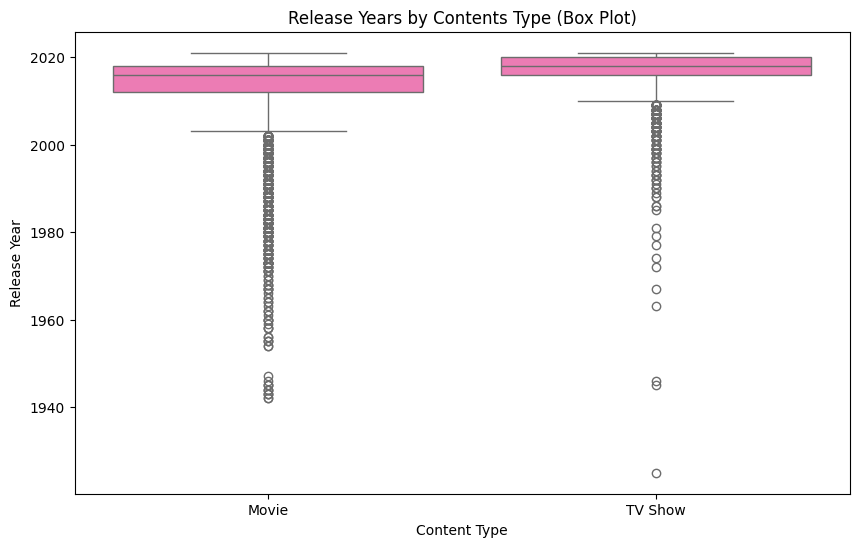

In [ ]:
# Release years by contents type (Box plot)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=updated_netflix_df,
    x='type',
    y='release_year',
    color='hotpink'
)

plt.title('Release Years by Contents Type (Box Plot)')
plt.xlabel('Content Type')
plt.ylabel('Release Year')

plt.show()

##<font color='dimgrey'>**Release years by contents type (Box plot)** </font>

<font color = 'slategrey'>
We conclude from the visual </font>


<font color = 'slategrey'>

Movie:
*  Min and Max year around 2001 and 2020
* Middle(Q2) is near around to 2020
* Quartile Q1 and Q2 lies between 2015 and 2019
* There outliers lies beyond the year 2000

TV Shows:
*  Min and Max year around 2014 and 2021
* Middle(Q2) is near around to 2017
* Quartile Q1 and Q2 lies between 2018 and 2020 or 2019
* There outliers lies beyond the year 2014


</font>

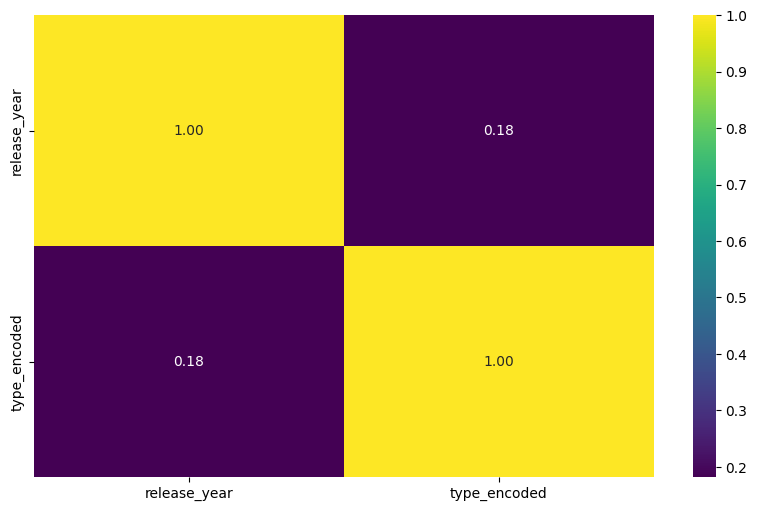

In [ ]:
from typing_extensions import type_repr
# Correlation analysis of release years and content type (Heatmap)

plt.figure(figsize=(10, 6))

type_encoding = {'Movie': 0, 'TV Show': 1}

updated_netflix_df['type_encoded'] = updated_netflix_df['type'].map(type_encoding)

# pivot_table = updated_netflix_df['release_year'].corr(updated_netflix_df['type_encoded'])

corr_matrix = updated_netflix_df[['release_year', 'type_encoded']].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    fmt='.2f'
)


plt.show()